<a href="https://colab.research.google.com/github/RonGopal/intro_to_AI/blob/main/Assignment15rrg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import shap

In [2]:
df = pd.read_csv('bank-loan.csv')

df.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB


In [5]:
df.isnull().sum()

,0
age,0
ed,0
employ,0
address,0
income,0
debtinc,0
creddebt,0
othdebt,0
default,150


In [6]:
# Handle missing values
df = df.dropna()

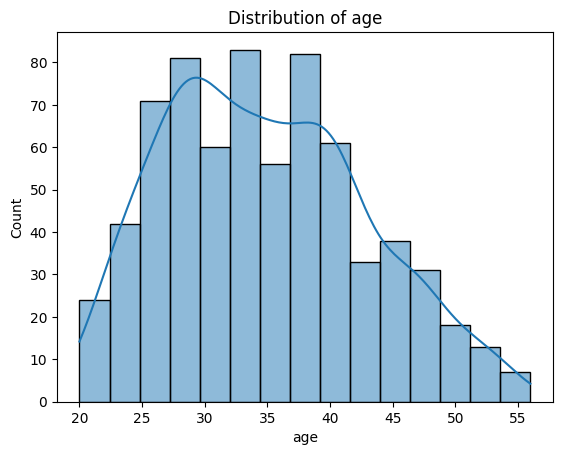

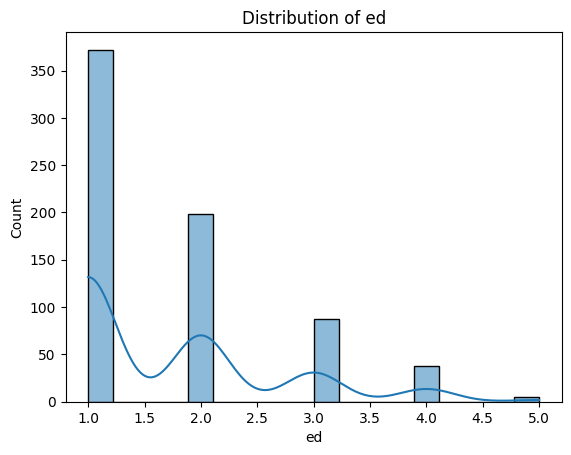

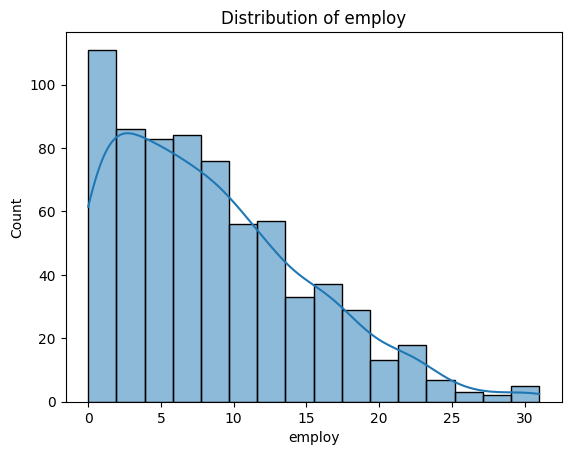

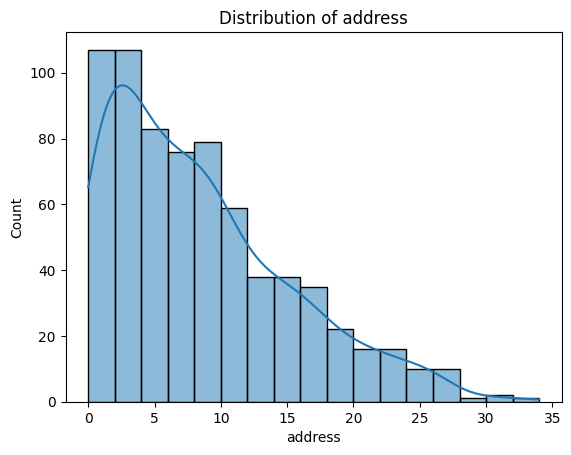

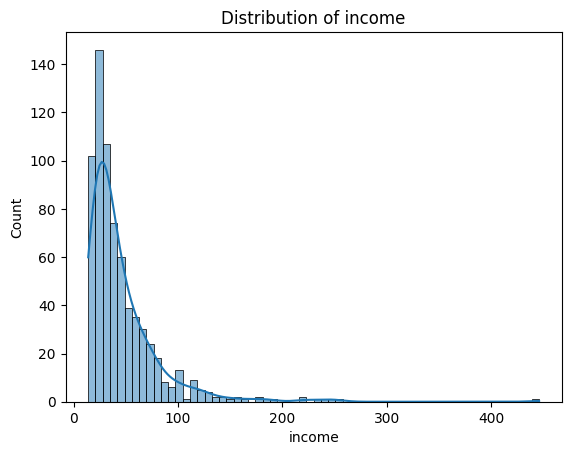

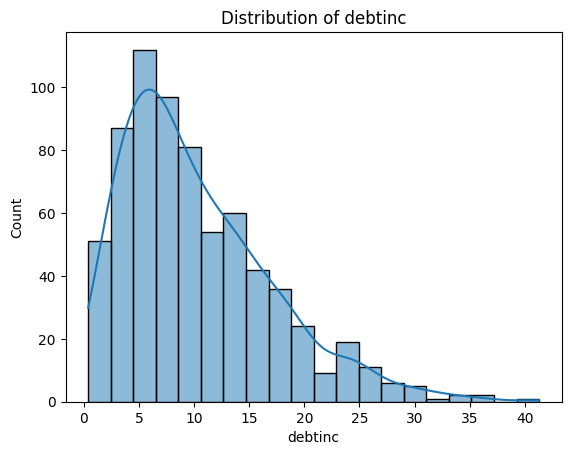

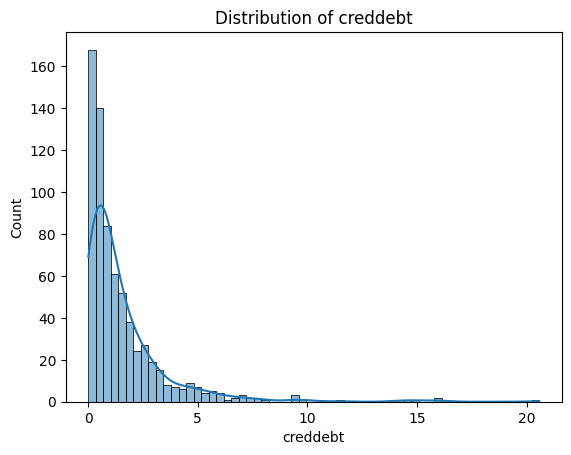

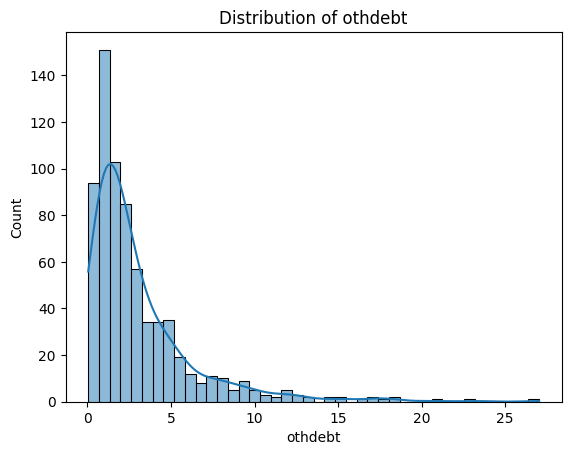

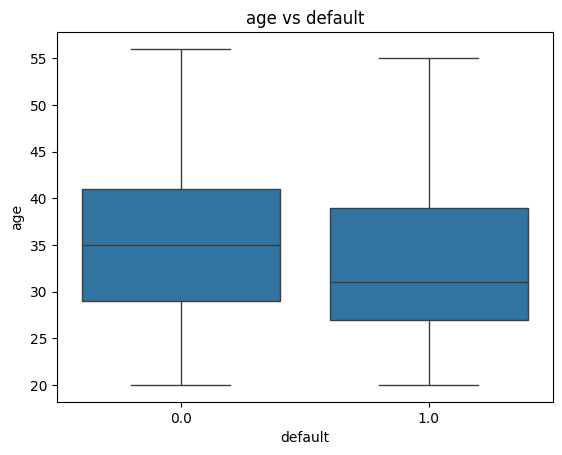

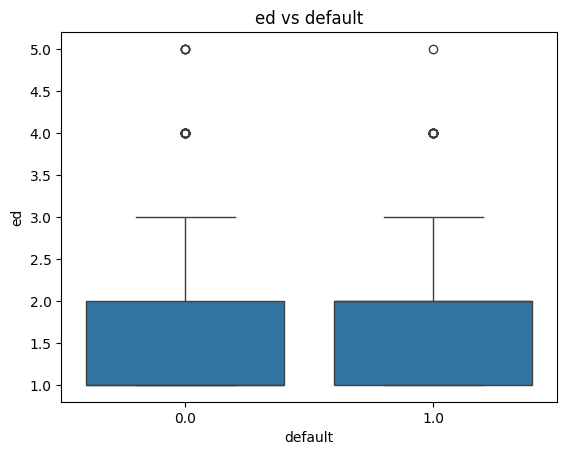

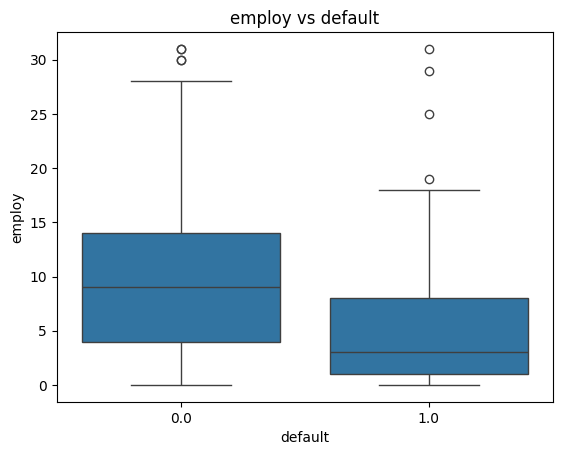

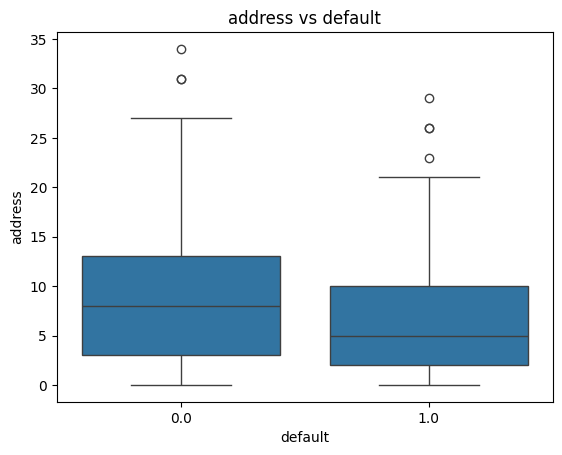

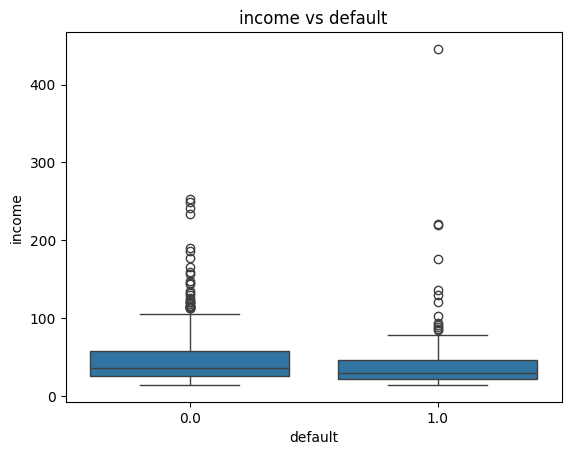

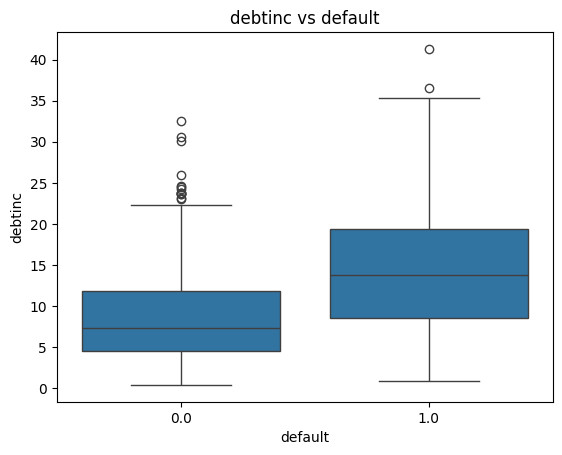

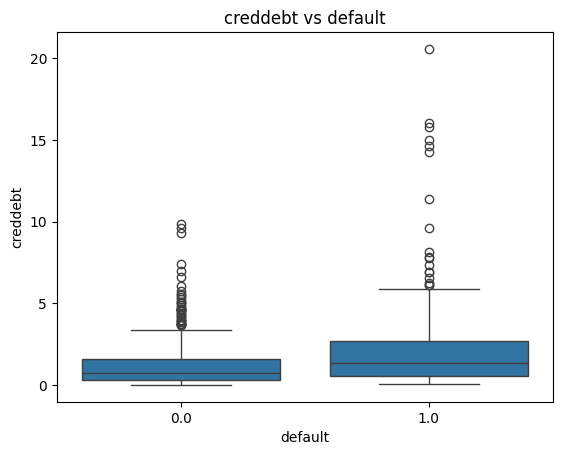

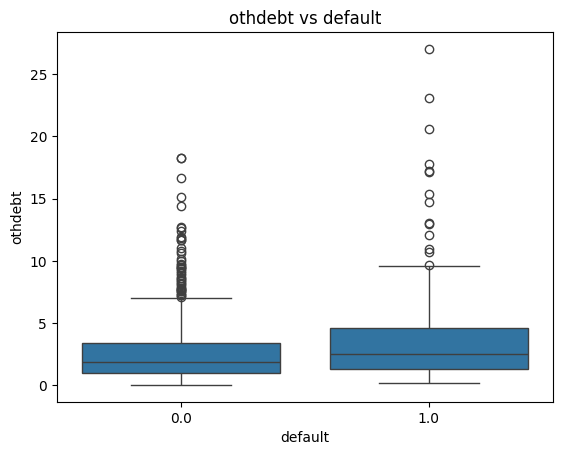

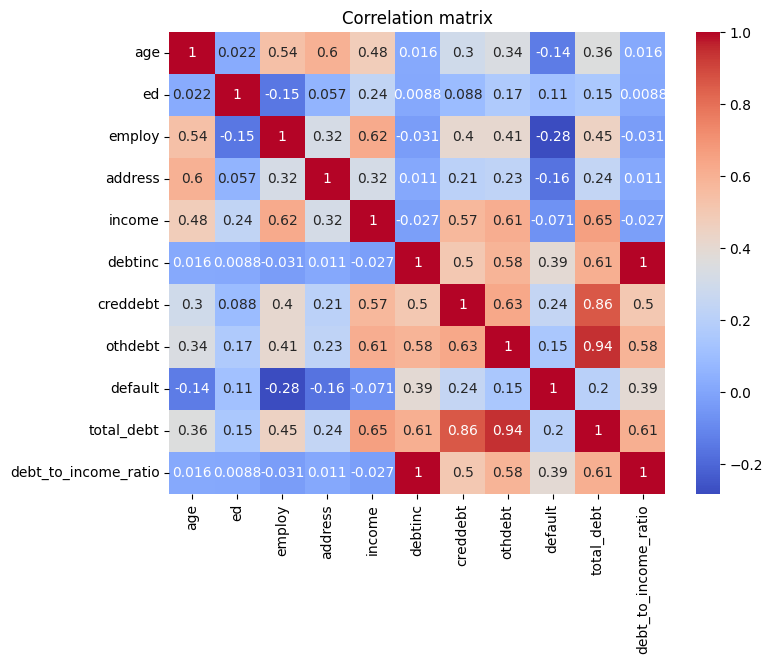

In [14]:
# Basic distributions
num_cols = ["age", "ed", "employ", "address", "income", "debtinc", "creddebt", "othdebt"]
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Relationship with target
for col in num_cols:
    plt.figure()
    sns.boxplot(x="default", y=col, data=df)
    plt.title(f"{col} vs default")
    plt.show()



# No categorical columns here; all are numeric already
# Optional: check correlations
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

In [8]:
# Feature engineering
df["total_debt"] = df["creddebt"] + df["othdebt"]
df["debt_to_income_ratio"] = df["total_debt"] / df["income"].replace(0, np.nan)
df["debt_to_income_ratio"] = df["debt_to_income_ratio"].fillna(0)

features = ["age", "ed", "employ", "address", "income",
            "debtinc", "creddebt", "othdebt",
            "total_debt", "debt_to_income_ratio"]
X = df[features]
y = df["default"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [10]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Feature importance
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print(feat_imp)

Accuracy: 0.8095238095238095
Confusion Matrix:
 [[137  18]
 [ 22  33]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.88      0.87       155
         1.0       0.65      0.60      0.62        55

    accuracy                           0.81       210
   macro avg       0.75      0.74      0.75       210
weighted avg       0.81      0.81      0.81       210

employ                  0.151475
debtinc                 0.132908
debt_to_income_ratio    0.124884
creddebt                0.118559
total_debt              0.099563
age                     0.093040
othdebt                 0.088727
address                 0.085585
income                  0.076837
ed                      0.028422
dtype: float64


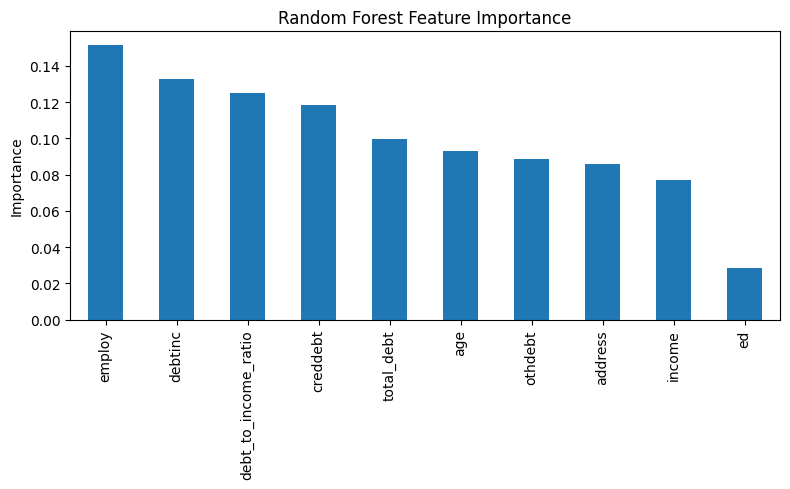

In [11]:
plt.figure(figsize=(8,5))
feat_imp.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

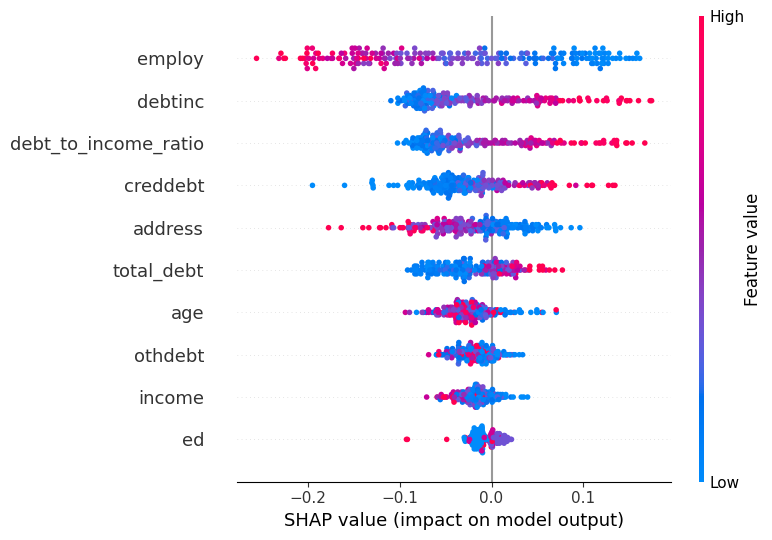

In [12]:
# SHAP for Random Forest
# Convert X_test (numpy array) to a pandas DataFrame with feature names
X_test_df = pd.DataFrame(X_test, columns=features)

explainer = shap.TreeExplainer(rf)
# Calculate SHAP values using the DataFrame for consistency
shap_values = explainer.shap_values(X_test_df)

# Global explanation (for class 1 = default)
# Assuming shap_values is (n_samples, n_features, n_classes)
shap.summary_plot(shap_values[:, :, 1], X_test_df, feature_names=features)

# Individual explanation
idx = 0  # example index
shap.force_plot(explainer.expected_value[1],
                shap_values[idx, :, 1],
                X_test_df.iloc[idx, :],
                feature_names=features)

In [13]:
df_test = df.iloc[y_test.index].copy()
df_test["age_group"] = pd.cut(df_test["age"],
                              bins=[0, 25, 35, 45, 100],
                              labels=["<=25", "26-35", "36-45", "46+"])

results = []
for group in df_test["age_group"].unique():
    mask = df_test["age_group"] == group
    if mask.sum() < 10:
        continue
    acc = accuracy_score(y_test[mask], y_pred[mask])
    cm = confusion_matrix(y_test[mask], y_pred[mask])
    results.append({"age_group": group, "accuracy": acc, "confusion_matrix": cm})

for r in results:
    print("\nAge group:", r["age_group"])
    print("Accuracy:", r["accuracy"])
    print("Confusion matrix:\n", r["confusion_matrix"])


Age group: <=25
Accuracy: 0.75
Confusion matrix:
 [[6 4]
 [1 9]]

Age group: 46+
Accuracy: 0.7619047619047619
Confusion matrix:
 [[13  2]
 [ 3  3]]

Age group: 36-45
Accuracy: 0.8333333333333334
Confusion matrix:
 [[55  7]
 [ 5  5]]

Age group: 26-35
Accuracy: 0.8144329896907216
Confusion matrix:
 [[63  5]
 [13 16]]


Debt burden strongest indicatior default.borrowers with high debt‑to‑income ratios, high debtinc, and high total debt (creddebt + othdebt) show substantially higher default rates. many defaulters of debtinc of 15%-20%. SHAP and feature importance elevates debtinc, total_debt and total_debt_to_income as top predicitors

borrowers with lower income <30K default more often especially with age is under <25 or have short employment history

Low employment duration <2 years have higher default rates because higher volitility in income, less credit history

younger people have default more often, lower income early in their career, have higher debt-to-income ratio and less credit experience

people with short address tenure default more often could because more finsncisly volitile and longer tenure tends to be more stable

cannot see any major fairness red flags with the model and dataset except false positives are higher for low incom younger people and false negatives are higher for older people with moderate debt

Accuracy hovered arounr 75% - 82% and precision and recall were quite balanced
